# PLOT OU - dc=0.01, tau=0.1, sampling 1microsec

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_time_series(time, omega_EKF, omega, delta_t, file_name):

    plt.figure(figsize=(10, 6))

    # plt.errorbar(data['time']*10**3, data['omega_EKF']*1e-3, yerr=np.sqrt(data['P_omega']), label='EKF', color='#ff7f0e', linestyle='-', linewidth=2)
    plt.plot(time*10**3, omega*1e-3, label='Simulation',  color='#ff7f0e', linestyle='-', linewidth=2)
    plt.plot(time*10**3, omega_EKF*1e-3, label='EKF', linestyle='-', linewidth=2, color='#1f77b4', marker='s', markerfacecolor='none', markeredgewidth=2, markevery=20)

    

    # Title and labels
    plt.xlabel('Time [ms]', fontsize=12)
    plt.ylabel(r'$\omega_L$ [kHz]', fontsize=12)
    delta_t *= 1e6
    plt.title(f'Δt = {delta_t:.1f} μs', fontsize=12)


    # Add grid lines
    plt.grid(which='both', linestyle='--', linewidth=0.5)

    # Legend
    legend = plt.legend(fontsize=10, loc='best', frameon=False, borderpad=1)

    # Adjust plot layout
    plt.tight_layout()

    # Save the plot
    plt.savefig('C:/Users/Klaudia/Documents/CD_EKF/OU_data/%s.pdf' %file_name)
    
def plot_err(time, omega_EKF, omega, P_omega, delta_t, file_name):
    plt.figure(figsize=(10, 6))


    plt.loglog(time*10**3, np.sqrt((omega_EKF-omega)**2), label="Estimation Error", color='#1f77b4', linestyle='-', linewidth=2)
    plt.loglog(time*10**3, np.sqrt(P_omega), label="Predicted Error by EKF", color='#ff7f0e', marker='s', markerfacecolor='none', markeredgewidth=2, markevery=20)

    plt.xlabel('Time [ms]', fontsize=12)
    plt.ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
    delta_t *= 1e6
    plt.title(f'Δt = {delta_t:.1f} μs', fontsize=12)
    # Add grid lines
    plt.grid(which='both', linestyle='--', linewidth=0.5)

    # Legend
    legend = plt.legend(fontsize=12, loc='best', frameon=True, borderpad=1)
    legend.get_frame().set_edgecolor('black')  # Set legend border color
    
    # Adjust plot layout
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('C:/Users/Klaudia/Documents/CD_EKF/OU_data/Err_OU_time_series_%s.pdf' %file_name)

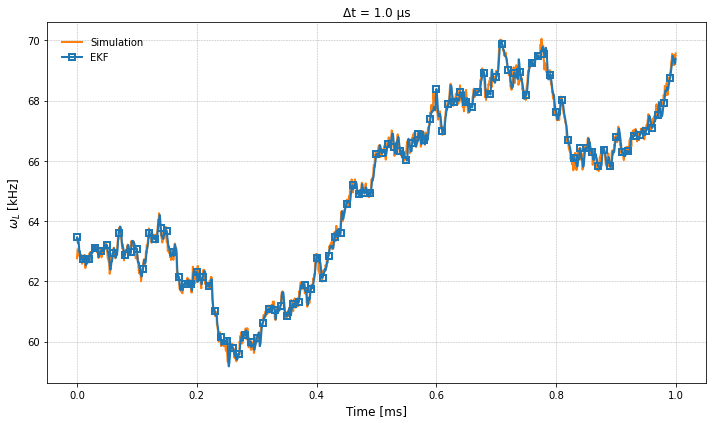

In [2]:

# Specify the path to your ODS file
# file_path = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_0.010000_tau_1000.000000_delta_0.000001"
# file_name = "OU_EKF_RELAXATION_dc_0.010000_tau_1000.000000_delta_0.000001" #dc=1e7

file_path = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_1.000000_tau_1000.000000_delta_0.000001"
file_name = "OU_EKF_RELAXATION_dc_1.000000_tau_1000.000000_delta_0.000001" #dc=1e9


# Load the ODS file
data = pd.read_csv(file_path)


plot_time_series(data['time'], data['omega_EKF'], data['omega'], delta_t=0.000001, file_name=file_name)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter


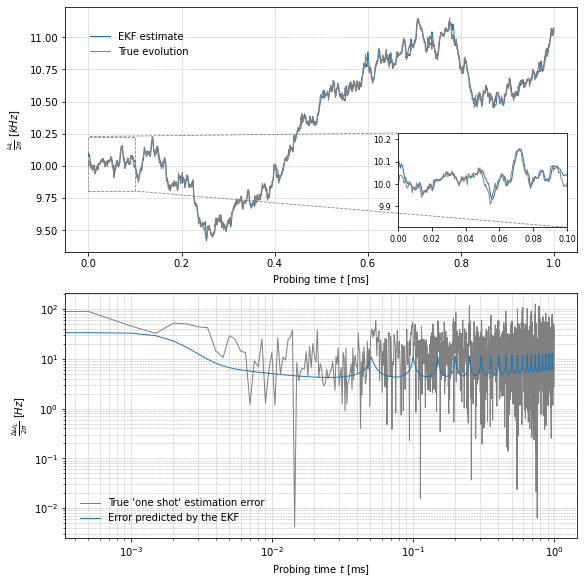

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), layout='constrained')

axs[0].plot(data['time']*10**3, data['omega_EKF']/(2*np.pi*10**3), label='EKF estimate', linestyle='-', linewidth=1, color='#1f77b4')
# axs[0].plot(data['time']*10**3, data['omega']/10**3, label='Simulation',  color='#f1c232', linestyle='-', linewidth=1)
axs[0].plot(data['time']*10**3, data['omega']/(2*np.pi*10**3), label='True evolution',  color='#808080', linestyle='-', linewidth=1)

# axs[0].plot(data['time']*10**3, )

# omega_ticks = axs[0].get_yticks()  # Get current y-ticks
# omega_ticks_2pi = omega_ticks / (2 * np.pi)  # Scale them to multiples of 2π
# axs[0].set_yticks(omega_ticks)  # Set the original y-ticks
# axs[0].set_yticklabels([f'$2\pi x {tick:.1f}$' for tick in omega_ticks_2pi])

# Title and labels
axs[0].set_xlabel(r'Probing time $t$ [ms]', fontsize=10)
axs[0].set_ylabel(r'$\frac{\omega_L}{2\pi} $ $[kHz]$', fontsize=10)
delta_t = 1e6*0.000001
# axs[0].text(f'Δt = {delta_t:.1f} μs', fontsize=12)

# # Custom tick label formatter
# def format_func(value, tick_position):
#     if value == 0:
#         return '0'
#     else:
#         # factor = 2 * np.pi  # Define the scale factor
#         factor = 6.28
#         scaled_value = value / factor  # Convert value to 2π scale
#         exponent = int(np.log10(scaled_value))  # Extract exponent
#         base = scaled_value / (10**exponent)  # Normalize base
# 
#         # formatted = f'2π×{scaled_value:.2f}'
#         formatted = f'{scaled_value:.2f}'
# 
#         return formatted
# 
# def format_func1(value, tick_position):
#     if value == 0:
#         return '0'
#     else:
#         # Convert the tick value to 2*pi*10^exponent format
#         factor = np.pi
#         exponent = int(np.log10(value))
#         base = value / (10**exponent)
#         formatted = f'{2*base:.0f}π×10$^{{{exponent}}}$'
#         return formatted
# 
# Apply the formatter to the y-axis
# axs[0].yaxis.set_major_formatter(FuncFormatter(format_func))

# Add grid lines
axs[0].grid(which='both', linestyle='--', linewidth=0.5)

# Legend
axs[0].legend(fontsize=10, frameon=False, borderpad=2, loc='upper left')


axs[1].loglog(data['time']*1e3, np.sqrt((data['omega_EKF']/(2*np.pi)-data['omega']/(2*np.pi))**2), label="True 'one shot' estimation error", color='#808080', linestyle='-', linewidth=1)
axs[1].loglog(data['time']*1e3, np.sqrt(data['P_omega'])/(2*np.pi), label="Error predicted by the EKF", color='#1f77b4', linestyle='-', linewidth=1)

axs[1].set_xlabel(r'Probing time $t$ [ms]', fontsize=10)
axs[1].set_ylabel(r'$\frac{\Delta \omega_L}{2\pi}$ $[Hz]$', fontsize=10)
delta_t *= 1e6
# axs[1].title(f'Δt = {delta_t:.1f} μs', fontsize=12)
# Add grid lines
# axs[1].yaxis.set_major_formatter(FuncFormatter(format_func1))

axs[1].grid(which='both', linestyle='--', linewidth=0.5)

# Legend
axs[1].legend(fontsize=10, frameon=False, loc='lower left', borderpad=1)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Inset axes inside axs[0]
axins = inset_axes(axs[0], width="30%", height="35%", loc='lower right',
# bbox_to_anchor=(0.01, 0.082, 0.96, 0.96),  # (x0, y0, width, height) #parameters for 1e7
# bbox_transform=axs[0].transAxes, borderpad=0)

bbox_to_anchor=(-0.12, 0.1, 1.1, 1.1),  # (x0, y0, width, height) #parameters for 1e9
bbox_transform=axs[0].transAxes, borderpad=0)

# Plot same data in inset
axins.plot(data['time']*1e3, data['omega_EKF']/(2*np.pi*1e3), linestyle='-', linewidth=1, color='#1f77b4')
axins.plot(data['time']*1e3, data['omega']/(2*np.pi*1e3), linestyle='-', linewidth=1, color='#808080')

# Set zoomed-in limits
axins.set_xlim(0.0, 0.1)

# Optional: use same Y-limits as full plot for consistent vertical scale
# Or compute tighter limits manually:
mask = (data['time']*1e3 >= 0.0) & (data['time']*1e3 <= 0.2)
y_min = min((data['omega_EKF'][mask]/(2*np.pi*1e3)).min(), (data['omega'][mask]/(2*np.pi*1e3)).min())
y_max = max((data['omega_EKF'][mask]/(2*np.pi*1e3)).max(), (data['omega'][mask]/(2*np.pi*1e3)).max())
axins.set_ylim(y_min * 0.99, y_max * 1.01)

# Match tick formatting to main axis
# axins.yaxis.set_major_formatter(FuncFormatter(format_func))

# Smaller ticks for inset
axins.tick_params(axis='both', which='major', labelsize=8)
axins.set_ylim(y_min, y_max)


mark_inset(axs[0], axins, loc1=2, loc2=4, fc="none", ec="0.5", linestyle='--', linewidth=0.8)

# y1, y2 = axs[0].get_ylim()  # Or use tighter bounds

# axs[0].axvspan(x1, x2, color='gray', alpha=0.1)

# Remove connector lines (do not use mark_inset)
# You can also set axins.set_xticks([]) or axins.set_yticks([]) to hide ticks if desired



plt.savefig("C:/Users/Klaudia/Documents/NEW_PLOTS/OU_Q_1e9.pdf")
# plt.savefig("C:/Users/Klaudia/Documents/NEW_PLOTS/OU_Q_1e7.pdf")

In [10]:

# Specify the path to your ODS file
# file_path = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_WIENER_dc_0.010000_tau_0.100000_delta_0.000001"
# file_name = "OU_EKF_WIENER_dc_0.010000_tau_0.100000_delta_0.000001"
# file_path = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_0.000001_tau_1000.000000_delta_0.000001"
# file_name = "OU_EKF_RELAXATION_dc_0.000001_tau_1000.000000_delta_0.000001"
file_path = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_1e-8_tau_1000.000000_delta_0.000001"
file_name = "OU_EKF_RELAXATION_dc_1e-8_tau_1000.000000_delta_0.000001"

# Load the ODS file
data = pd.read_csv(file_path)


plot_time_series(data['time'], data['omega_EKF'], data['omega'], delta_t=0.000001, file_name=file_name)


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_1e-8_tau_1000.000000_delta_0.000001'

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(2, 1, layout='constrained')

axs[0].plot(data['time'] * 10 ** 3, data['omega'] * 1e-3, label='Simulation', color='#ff7f0e', linestyle='-',
            linewidth=2)
axs[0].plot(data['time'] * 10 ** 3, data['omega_EKF'] * 1e-3, label='EKF', linestyle='-', linewidth=2, color='#1f77b4')

# Title and labels
axs[0].set_xlabel('Time [ms]', fontsize=12)
axs[0].set_ylabel(r'$\omega_L$ [kHz]', fontsize=12)
delta_t = 1e6 * 0.000001
# axs[0].text(f'Δt = {delta_t:.1f} μs', fontsize=12)

ax_inset = inset_axes(axs[0], width="45%", height="45%", loc="center")  # Adjust size and location
ax_inset.plot(data['time'] * 10 ** 3, data['omega'] * 1e-3,  color='#ff7f0e')  # Red curve in the inset
ax_inset.plot(data['time'] * 10 ** 3, data['omega_EKF'] * 1e-3,  color='#1f77b4')
ax_inset.set_xlim(data['time'][100] * 10 ** 3, 1)  # Zoom into a specific region
ax_inset.set_ylim(data['omega'][100] * 1e-3+0.001, data['omega'][100] * 1e-3-0.001)
# ax_inset.set_xticks([])
# ax_inset.set_yticks([])


# Add grid lines
axs[0].grid(which='both', linestyle='--', linewidth=0.5)

# Legend
axs[0].legend(fontsize=10, frameon=False, borderpad=1)

axs[1].loglog(data['time'] * 10 ** 3, (data['omega_EKF'] - data['omega']) ** 2, label="Estimation Error",
              color='#ff7f0e', linestyle='-', linewidth=2)
axs[1].loglog(data['time'] * 10 ** 3, data['P_omega'], label="Error predicted by EKF", color='#1f77b4')

axs[1].set_xlabel('Time [ms]', fontsize=12)
axs[1].set_ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
delta_t *= 1e6
# axs[1].title(f'Δt = {delta_t:.1f} μs', fontsize=12)
# Add grid lines
axs[1].grid(which='both', linestyle='--', linewidth=0.5)

# Legend
axs[1].legend(fontsize=10, frameon=False, loc='best')
plt.savefig("OU_like_relaxation_dominated_dc_10.png")

In [ ]:
plot_err(data['time'], data['omega_EKF'], data['omega'], data['P_omega'], delta_t=0.000001, file_name=file_name)

#OU sampling 5mus

In [ ]:
 # Specify the path to your ODS file
file_path1 = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_dc_0.010000_tau_0.100000_delta_0.000005"
file_name1 = 'OU_EKF_dc_0.010000_tau_0.100000_delta_0.000005'

# Load the ODS file
data1 = pd.read_csv(file_path1)

plot_time_series(data1['time'], data1['omega_EKF'], data1['omega'], delta_t=0.000005, file_name=file_name1)
plot_err(data1['time'], data1['omega_EKF'], data1['omega'], data1["P_omega"], delta_t=0.000005, file_name=file_name1)

In [ ]:
file_path2 = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_RELAXATION_dc_0.000001_tau_1000.000000_delta_0.000001"
file_name2 = 'OU_EKF_RELAXATION_dc_0.000001_tau_1000.000000_delta_0.000001'

# Load the ODS file
data2 = pd.read_csv(file_path2)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000005, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000005, file_name=file_name2)

In [ ]:
file_path2 = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_dc_0.010000_tau_0.010000_delta_0.000001"
file_name2 = 'OU_EKF_dc_0.010000_tau_0.010000_delta_0.000001'

# Load the ODS file
data2 = pd.read_csv(file_path2)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000001, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000001, file_name=file_name2)

In [ ]:
file_path2 = "C:/Users/Klaudia/Documents/CD_EKF/OU_data/OU_EKF_dc_0.100000_tau_1000.000000_delta_0.000001"
file_name2 = 'OU_EKF_dc_0.100000_tau_1000.000000_delta_0.000001'
file_path_WIENER_EKF_TRUE_DC = "C:/Users\Klaudia\Documents\CD_EKF\OU_data\OU_EKF_WIENER_dc_0.100000_tau_1000.000000_delta_0.000001"
file_name_WIENER_EKF_TRUE_DC = "OU_EKF_WIENER_dc_0.100000_tau_1000.000000_delta_0.000001"
file_path_WIENER_EKF_WRONG_DC = "C:/Users\Klaudia\Documents\CD_EKF\OU_data\OU_EKF_WIENER_dc_0.100000_tau_1000.000000_delta_0.000001"
file_name_WIENER_EKF_WRONG_DC = "OU_EKF_WIENER_dc_0.100000_tau_1000.000000_delta_0.000001"

# Load the ODS file
data2 = pd.read_csv(file_path2)
data3 = pd.read_csv(file_path_WIENER_EKF_WRONG_DC)
data4 = pd.read_csv(file_path_WIENER_EKF_TRUE_DC)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000001, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000001, file_name=file_name2)

In [11]:
plot_err(data3['time'], data3['omega_EKF'], data3['omega'], data3["P_omega"], delta_t=0.000001, file_name=file_name2)

NameError: name 'data3' is not defined

In [12]:
plt.figure(figsize=(10, 6))
delta_t=0.000001 
plt.loglog(data3["time"]*10**3, (data3['omega_EKF'] - data3['omega'])**2, label="Estimation Error", linestyle='-', linewidth=2)
plt.loglog(data3["time"]*10**3, data3["P_omega"], label="Predicted Error by EKF")
plt.loglog(data2["time"]*10**3, (data2['omega_EKF'] - data2['omega'])**2, label="Estimation Error OU EKF", linestyle='-', linewidth=2)
plt.loglog(data2["time"]*10**3, data2["P_omega"], label="Predicted Error by OU EKF")

plt.xlabel('Time [ms]', fontsize=12)
plt.ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
delta_t *= 1e6
plt.title(f'Δt = {delta_t:.1f} μs', fontsize=14)
# Add grid lines
plt.grid(which='both', linestyle='--', linewidth=0.5)

# Legend
legend = plt.legend(fontsize=12, loc='best', frameon=True, borderpad=1)
legend.get_frame().set_edgecolor('black')  # Set legend border color

# Adjust plot layout
plt.tight_layout()

NameError: name 'data3' is not defined

<Figure size 720x432 with 0 Axes>

In [13]:
#Calculate dc
N_at = 0.44 * 1e12  # Number of atoms
q = 0.198
T2=0.87*1e-3
print(N_at*q/T2)
dc_rescaled = 0.001
dc_real = dc_rescaled*N_at*q/2
print(dc_real)

print(T2**2*dc_rescaled)

100137931034482.77
43560000.0
7.569e-10


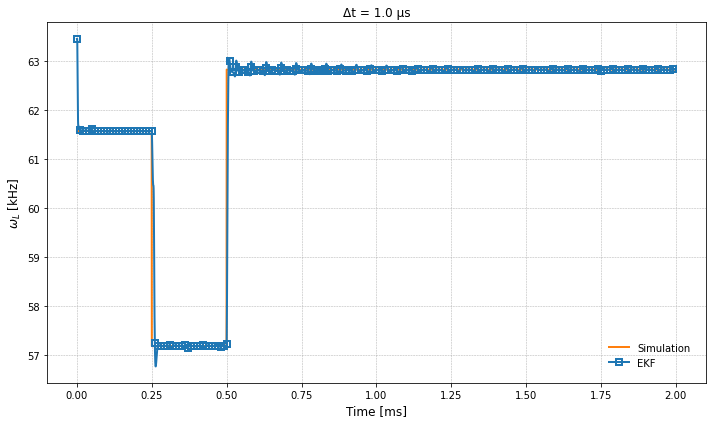

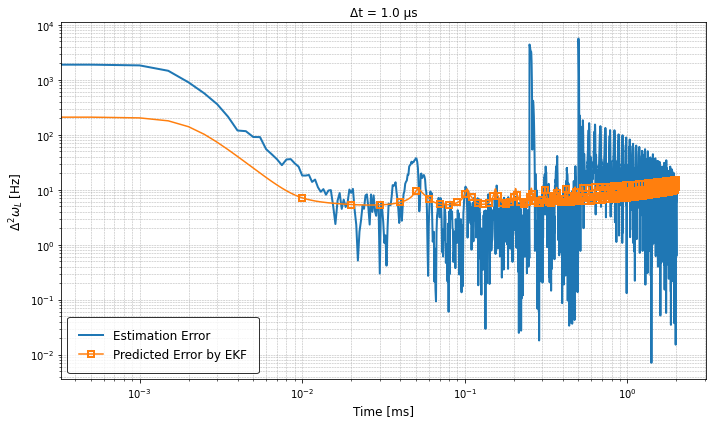

In [12]:
# file_path2 = "C:/Users\Klaudia\Documents\CD_EKF\jump_data\jump_EKF_dc_0.001000_tau_0.001000_delta_0.000001"
# file_name2 = 'jump_EKF_dc_0.001000_tau_0.001000_delta_0.000001'

file_path2 = "C:/Users/Klaudia\Downloads\Data_March2026/jump_EKF_dc_0.010000_tau_0.001000_delta_0.000001"
file_name2 = 'jump_EKF_dc_0.010000_tau_0.001000_delta_0.000001'

file_path21 = "C:/Users/Klaudia\Downloads\Data_March2026/jump_EKF_dc_0.100000_tau_0.001000_delta_0.000001"
file_path22 = "C:/Users/Klaudia\Downloads\Data_March2026/jump_EKF_dc_1.000000_tau_0.001000_delta_0.000001"

# Load the ODS file

#dc_sim = 0.01 (1e7), 0.1 (1e8), 1.0 (1e9)
data2 = pd.read_csv(file_path2) #(1e7)
data21 = pd.read_csv(file_path21) #(1e8)
data22 = pd.read_csv(file_path22) #(1e9)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000001, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000001, file_name=file_name)

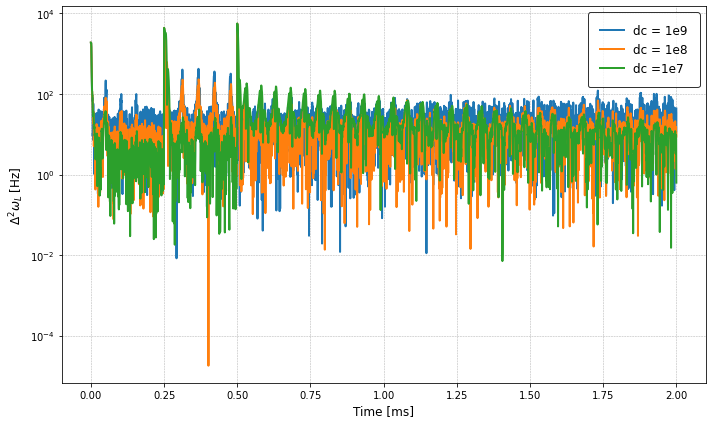

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(data22['time']*10**3, np.sqrt((data22['omega_EKF']-data22['omega'])**2), label="dc = 1e9",  linestyle='-', linewidth=2)
plt.plot(data21['time']*10**3, np.sqrt((data21['omega_EKF']-data21['omega'])**2), label="dc = 1e8", linestyle='-', linewidth=2)
plt.plot(data2['time']*10**3, np.sqrt((data2['omega_EKF']-data2['omega'])**2), label="dc =1e7", linestyle='-', linewidth=2)


# plt.plot(data2['time']*10**3, np.sqrt(P_omega), label="Predicted Error by EKF", color='#ff7f0e', marker='s', markerfacecolor='none', markeredgewidth=2, markevery=20)

plt.xlabel('Time [ms]', fontsize=12)
plt.ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
plt.yscale('log')
# delta_t *= 1e6
# plt.title(f'Δt = {delta_t:.1f} μs', fontsize=12)
# Add grid lines
plt.grid(which='both', linestyle='--', linewidth=0.5)

# Legend
legend = plt.legend(fontsize=12, loc='best', frameon=True, borderpad=1)
legend.get_frame().set_edgecolor('black')  # Set legend border color

# Adjust plot layout
plt.tight_layout()

# Save the plot
plt.savefig('C:/Users/Klaudia/Documents/CD_EKF/OU_data/Err_step_time_series_%s.pdf' %file_name)

5.0028643459159 15.555595271793104


PermissionError: [Errno 13] Permission denied: 'C:/Users/Klaudia/Documents/NEW_PLOTS/jump.pdf'

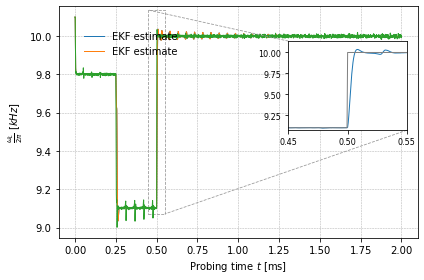

In [25]:
fig, axs = plt.subplots(1,1)

axs.plot(data2['time']*10**3, data2['omega_EKF']*1e-3/(2*np.pi), label='EKF estimate', linestyle='-', linewidth=1)
axs.plot(data21['time']*10**3, data21['omega_EKF']*1e-3/(2*np.pi), label='EKF estimate', linestyle='-', linewidth=1)
axs.plot(data22['time']*10**3, data22['omega_EKF']*1e-3/(2*np.pi), label='', linestyle='-', linewidth=1)
# axs.plot(data2['time']*10**3, data2['omega']*1e-3/(2*np.pi), label='True evolution',  color='#808080', linestyle='-', linewidth=2)

# Title and labels

delta_t = 1e6*0.000001
# axs[0].text(f'Δt = {delta_t:.1f} μs', fontsize=14)


# Add grid lines
axs.grid(which='both', linestyle='--', linewidth=0.5)
# axs.set_ylim(60,80)
# Legend
axs.legend(fontsize=10, frameon=False, borderpad=2, loc='upper left')

# # Custom tick label formatter
# def format_func(value, tick_position):
#     if value == 0:
#         return '0'
#     else:
#         factor = 2 * np.pi  # Define the scale factor
#         scaled_value = value / factor  # Convert value to 2π scale
#         exponent = int(np.log10(scaled_value))  # Extract exponent
#         base = scaled_value / (10**exponent)  # Normalize base
# 
#         formatted = f'2π×{scaled_value:.1f}'
#         return formatted


# Apply the formatter to the y-axis
# axs.yaxis.set_major_formatter(FuncFormatter(format_func))
axs.set_xlabel(r'Probing time $t$ [ms]', fontsize=10)
axs.set_ylabel(r'$\frac{\omega_L}{2\pi}$ $[kHz]$', fontsize=10)

# axs[1].loglog(data2['time']*10**3, (data2['omega_EKF']-data2['omega'])**2, label="Estimation Error", color='#ff7f0e', linestyle='-', linewidth=2)
# axs[1].loglog(data2['time']*10**3, data2['P_omega'], label="Error predicted by EKF", color='#1f77b4')
# 
# axs[1].set_xlabel('Time [ms]', fontsize=12)
# axs[1].set_ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
# delta_t *= 1e6
# # axs[1].title(f'Δt = {delta_t:.1f} μs', fontsize=14)
# # Add grid lines
# axs[1].grid(which='both', linestyle='--', linewidth=0.5)
# 
# # Legend
# axs[1].legend(fontsize=10, loc='best')
plt.tight_layout()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Inset axes inside axs[0]
axins = inset_axes(axs, width="30%", height="35%", loc='upper right',
                   # bbox_to_anchor=(0.17, -0.15, 1.1, 1.1),  # (x0, y0, width, height) #parameters for 1e7
                   # bbox_transform=axs[0].transAxes, borderpad=0)

                   bbox_to_anchor=(-0.13, -0.25, 1.1, 1.1),  # (x0, y0, width, height) #parameters for 1e9
                   bbox_transform=axs.transAxes, borderpad=0)

# Plot same data in inset
axins.plot(data2['time']*1e3, data2['omega_EKF']/(1e3*2*np.pi), linestyle='-', linewidth=1, color='#1f77b4')
axins.plot(data2['time']*1e3, data2['omega']/(1e3*2*np.pi), linestyle='-', linewidth=1, color='#808080')

# Set zoomed-in limits
axins.set_xlim(0.45, 0.55)

# Optional: use same Y-limits as full plot for consistent vertical scale
# Or compute tighter limits manually:
mask = (data2['time']*1e3 >= 0.45) & (data2['time']*1e3 <= 0.55)
y_min = min((data2['omega_EKF'][mask]/(1e3*2*np.pi)).min(), (data2['omega'][mask]/(1e3*2*np.pi)).min())
y_max = max((data2['omega_EKF'][mask]/(1e3*2*np.pi)).max(), (data2['omega'][mask]/(1e3*2*np.pi)).max())
print(y_min * 0.55, y_max * 1.55)
axins.set_ylim(y_min * 0.55, y_max * 1.55)

# Match tick formatting to main axis
# axins.yaxis.set_major_formatter(FuncFormatter(format_func))

# Smaller ticks for inset
axins.tick_params(axis='both', which='major', labelsize=8)

x1, x2 = 0.45, 0.55  # ms
axins.set_xlim(x1, x2)
axins.set_ylim(y_min-0.025, y_max+0.1)

mark_inset(axs, axins, loc1=2, loc2=4, fc="none", ec="0.6", linestyle='--', linewidth=0.8)

# y1, y2 = axs[0].get_ylim()  # Or use tighter bounds

# axs[0].axvspan(x1, x2, color='gray', alpha=0.1)
plt.savefig("C:/Users/Klaudia/Documents/NEW_PLOTS/jump.pdf")

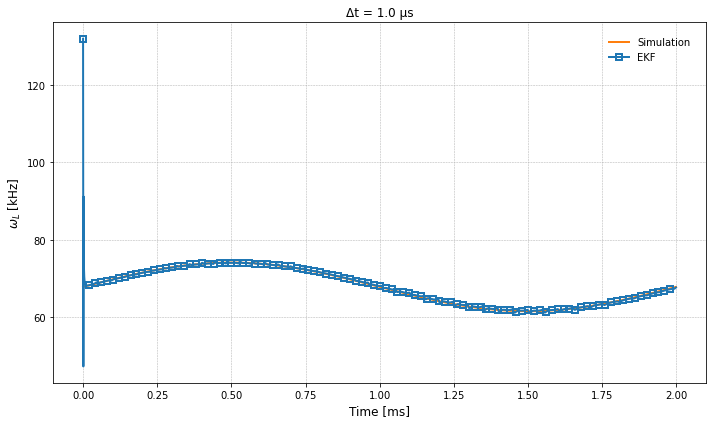

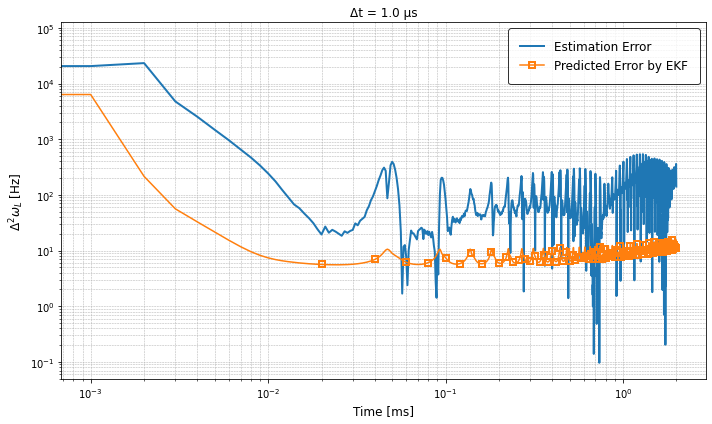

In [85]:
file_path2 = "C:/Users/Klaudia\Documents\CD_EKF\sin_data\sin_EKF_dc_0.010000_tau_1000.000000_delta_0.000001_new"

file_name2 = 'sin_EKF_dc_0.010000_tau_1000.000000_delta_0.000001_new'

# Load the ODS file
data2 = pd.read_csv(file_path2)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000001, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000001, file_name=file_name2)

58.01498691918485 7.442085552412775


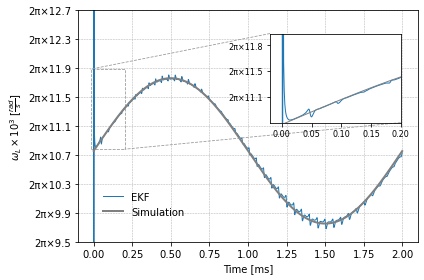

In [107]:
fig, axs = plt.subplots(1,1)

axs.plot(data2['time']*10**3, data2['omega_EKF']*1e-3, label='EKF', linestyle='-', linewidth=1, color='#1f77b4')
axs.plot(data2['time']*10**3, data2['omega']*1e-3, label='Simulation',  color='#808080', linestyle='-', linewidth=2)

axs.set_ylim(60,80)

# Title and labels

delta_t = 1e6*0.000001
# axs[0].text(f'Δt = {delta_t:.1f} μs', fontsize=14)


# Add grid lines
axs.grid(which='both', linestyle='--', linewidth=0.5)
# axs.set_ylim(60,80)
# Legend
axs.legend(fontsize=10, frameon=False, borderpad=2, loc='lower left')

# Custom tick label formatter
def format_func(value, tick_position):
    if value == 0:
        return '0'
    else:
        factor = 2 * np.pi  # Define the scale factor
        scaled_value = value / factor  # Convert value to 2π scale
        exponent = int(np.log10(scaled_value))  # Extract exponent
        base = scaled_value / (10**exponent)  # Normalize base

        formatted = f'2π×{scaled_value:.1f}'
        return formatted


# Apply the formatter to the y-axis
axs.yaxis.set_major_formatter(FuncFormatter(format_func))
axs.set_xlabel('Time [ms]', fontsize=10)
axs.set_ylabel(r'$\omega_L \times 10^{3}$ $[\frac{rad}{s}]$', fontsize=10)

# axs[1].loglog(data2['time']*10**3, (data2['omega_EKF']-data2['omega'])**2, label="Estimation Error", color='#ff7f0e', linestyle='-', linewidth=2)
# axs[1].loglog(data2['time']*10**3, data2['P_omega'], label="Error predicted by EKF", color='#1f77b4')
# 
# axs[1].set_xlabel('Time [ms]', fontsize=12)
# axs[1].set_ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
# delta_t *= 1e6
# # axs[1].title(f'Δt = {delta_t:.1f} μs', fontsize=14)
# # Add grid lines
# axs[1].grid(which='both', linestyle='--', linewidth=0.5)
# 
# # Legend
# axs[1].legend(fontsize=10, loc='best')
plt.tight_layout()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Inset axes inside axs[0]
axins = inset_axes(axs, width="35%", height="35%", loc='upper right',
                   # bbox_to_anchor=(0.17, -0.15, 1.1, 1.1),  # (x0, y0, width, height) #parameters for 1e7
                   # bbox_transform=axs[0].transAxes, borderpad=0)

                   bbox_to_anchor=(-0.15, -0.2, 1.1, 1.1),  # (x0, y0, width, height) #parameters for 1e9
                   bbox_transform=axs.transAxes, borderpad=0)

# Plot same data in inset
axins.plot(data2['time']*1e3, data2['omega_EKF']/1e3, linestyle='-', linewidth=1, color='#1f77b4')
axins.plot(data2['time']*1e3, data2['omega']/1e3, linestyle='-', linewidth=1, color='#808080')

# Set zoomed-in limits
axins.set_xlim(0.0, 0.2)

# Optional: use same Y-limits as full plot for consistent vertical scale
# Or compute tighter limits manually:
mask = (data2['time']*1e3 >= 0.02) & (data2['time']*1e3 <= 0.55)
y_min = min((data2['omega_EKF'][mask]/1e3).min(), (data2['omega'][mask]/1e3).min())
y_max = max((data2['omega_EKF'][mask]/1e3).max(), (data2['omega'][mask]/1e3).max())
print(y_min * 0.85, y_max * 0.1)
axins.set_ylim(y_min * 0.55, y_max * 0.55)

# Match tick formatting to main axis
axins.yaxis.set_major_formatter(FuncFormatter(format_func))

# Smaller ticks for inset
axins.tick_params(axis='both', which='major', labelsize=8)

x1, x2 = -0.02, 0.2  # ms
axins.set_xlim(x1, x2)
mark_inset(axs, axins, loc1=2, loc2=4, fc="none", ec="0.6", linestyle='--', linewidth=0.8)

# y1, y2 = axs[0].get_ylim()  # Or use tighter bounds
axins.set_ylim(y_min-0.25, y_max+0.5)

# axs[0].axvspan(x1, x2, color='gray', alpha=0.1)
plt.savefig("sin.pdf")

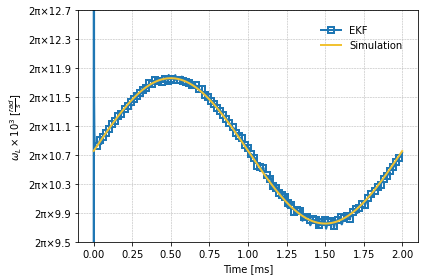

In [37]:
fig, axs = plt.subplots(1,1)

axs.plot(data2['time']*10**3, data2['omega_EKF']*1e-3, label='EKF', linestyle='-', linewidth=2, color='#1f77b4', marker='s', markerfacecolor='none', markeredgewidth=2, markevery=20)
axs.plot(data2['time']*10**3, data2['omega']*1e-3, label='Simulation',  color='#f1c232', linestyle='-', linewidth=2)



# Title and labels
axs.set_xlabel('Time [ms]', fontsize=10)
axs.set_ylabel(r'$\omega_L \times 10^{3}$ $[\frac{rad}{s}]$', fontsize=10)
axs.set_ylim(60,80)

delta_t = 1e6*0.000001
# axs[0].text(f'Δt = {delta_t:.1f} μs', fontsize=14)
# Custom tick label formatter
def format_func(value, tick_position):
    if value == 0:
        return '0'
    else:
        factor = 2 * np.pi  # Define the scale factor
        scaled_value = value / factor  # Convert value to 2π scale
        exponent = int(np.log10(scaled_value))  # Extract exponent
        base = scaled_value / (10**exponent)  # Normalize base

        formatted = f'2π×{scaled_value:.1f}'
        return formatted


# Apply the formatter to the y-axis
axs.yaxis.set_major_formatter(FuncFormatter(format_func))

# Add grid lines
axs.grid(which='both', linestyle='--', linewidth=0.5)

# Legend
axs.legend(fontsize=10, frameon=False, borderpad=1)
plt.tight_layout()

plt.savefig("sin.pdf")


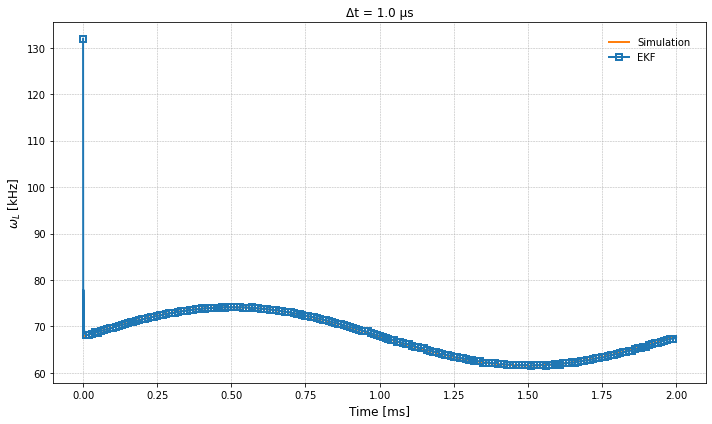

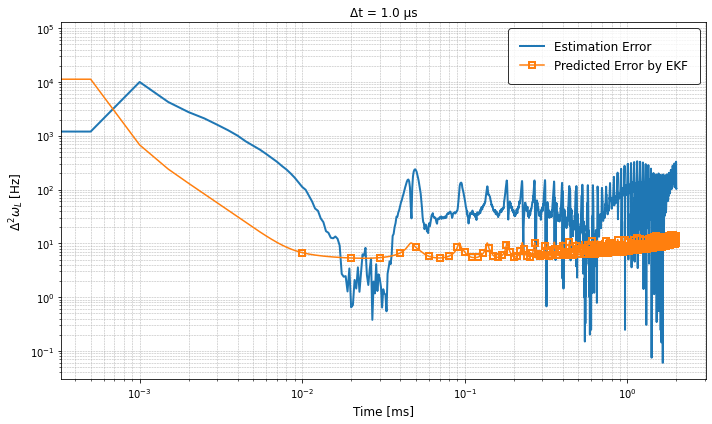

In [16]:
# file_name2 = 'jump_EKF_dc_0.001000_tau_0.001000_delta_0.000001'

file_path2 = "C:/Users/Klaudia\Downloads\Data_March2026/sin_EKF_dc_0.010000_tau_1000.000000_delta_0.000001_new1"
file_name2 = 'sin_EKF_dc_0.010000_tau_1000.000000_delta_0.000001_new1'

file_path21 = "C:/Users/Klaudia\Downloads\Data_March2026/sin_EKF_dc_0.100000_tau_1000.000000_delta_0.000001_new1"
file_path22 = "C:/Users/Klaudia\Downloads\Data_March2026/sin_EKF_dc_1.000000_tau_1000.000000_delta_0.000001_new1"

# Load the ODS file

#dc_sim = 0.01 (1e7), 0.1 (1e8), 1.0 (1e9)
data2 = pd.read_csv(file_path2) #(1e7)
data21 = pd.read_csv(file_path21) #(1e8)
data22 = pd.read_csv(file_path22) #(1e9)

plot_time_series(data2['time'], data2['omega_EKF'], data2['omega'], delta_t=0.000001, file_name=file_name2)
plot_err(data2['time'], data2['omega_EKF'], data2['omega'], data2["P_omega"], delta_t=0.000001, file_name=file_name)

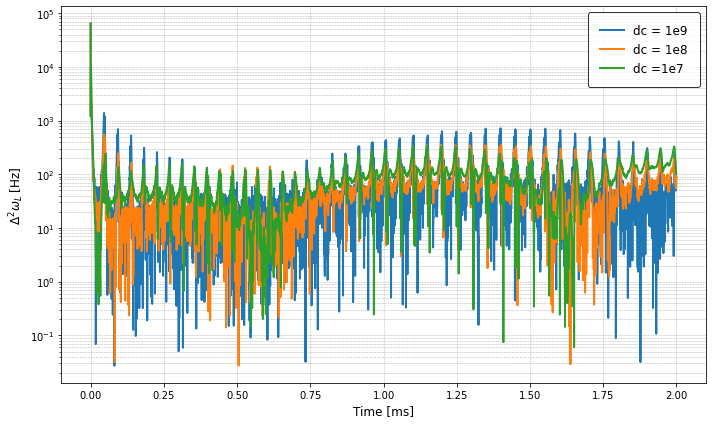

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(data22['time']*10**3, np.sqrt((data22['omega_EKF']-data22['omega'])**2), label="dc = 1e9",  linestyle='-', linewidth=2)
plt.plot(data21['time']*10**3, np.sqrt((data21['omega_EKF']-data21['omega'])**2), label="dc = 1e8", linestyle='-', linewidth=2)
plt.plot(data2['time']*10**3, np.sqrt((data2['omega_EKF']-data2['omega'])**2), label="dc =1e7", linestyle='-', linewidth=2)


# plt.plot(data2['time']*10**3, np.sqrt(P_omega), label="Predicted Error by EKF", color='#ff7f0e', marker='s', markerfacecolor='none', markeredgewidth=2, markevery=20)

plt.xlabel('Time [ms]', fontsize=12)
plt.ylabel(r'$\Delta^2 \omega_L$ [Hz]', fontsize=12)
plt.yscale('log')
# delta_t *= 1e6
# plt.title(f'Δt = {delta_t:.1f} μs', fontsize=12)
# Add grid lines
plt.grid(which='both', linestyle='--', linewidth=0.5)

# Legend
legend = plt.legend(fontsize=12, loc='best', frameon=True, borderpad=1)
legend.get_frame().set_edgecolor('black')  # Set legend border color

# Adjust plot layout
plt.tight_layout()

# Save the plot
plt.savefig('C:/Users/Klaudia/Documents/CD_EKF/OU_data/Err_sin_time_series_%s.pdf' %file_name)